# Exercise 4: Chemostat Analysis (Yeast Biomass Production)

Steady-state chemostat data for yeast growth:
- Feed substrate concentration: $S_0 = 10$ g/L
- Excess oxygen provided

### Key equations (Monod kinetics with maintenance)

**Monod growth rate:**
$$\mu = \frac{\mu_{max} \cdot S}{K_s + S}$$

**At steady state in chemostat:** $\mu = D$

$$S = \frac{D \cdot K_s}{\mu_{max} - D}$$

**Substrate balance (with maintenance):**
$$r_s = \frac{r_X}{Y_{X/S}} + m \cdot X$$

At steady state: $D(S_0 - S) = r_s = \frac{\mu X}{Y_{X/S}} + m \cdot X = \frac{D \cdot X}{Y_{X/S}} + m \cdot X$

$$X = \frac{Y_{X/S}(S_0 - S)}{1 + m \cdot Y_{X/S}/D}$$

**Productivity:** $P = D \cdot X$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from scipy.stats import linregress

In [2]:
# Data

D = np.array([0.05,0.1,0.2,0.4,0.6,0.7,0.8,0.84])  # dilution rate [1/h]
S = np.array([0.012,0.028,0.05,0.1,0.15,0.176,0.8,9])  # substrate conc [g/L]
X = np.array([3.20, 3.70, 4.00, 4.40, 4.75, 4.90, 4.50, 0.50])  # cell conc [g/L]

S0 = 10.0  # g/L  feed substrate

# Remove washout points
D_fit = D[:7]
X_fit = X[:7]
S_fit = S[:7]

print("Experimental Data:")
print(f"{'D (h⁻¹)':>10} {'X (g/L)':>10} {'S (g/L)':>10}")
for d, x, s in zip(D, X, S):
    print(f"{d:10.3f} {x:10.3f} {s:10.3f}")

Experimental Data:
   D (h⁻¹)    X (g/L)    S (g/L)
     0.050      3.200      0.012
     0.100      3.700      0.028
     0.200      4.000      0.050
     0.400      4.400      0.100
     0.600      4.750      0.150
     0.700      4.900      0.176
     0.800      4.500      0.800
     0.840      0.500      9.000


### Part (a): Estimate $\mu_{max}$ and $K_s$ (Monod kinetics)

At steady state $\mu = D$, so we fit the Monod equation directly:
$$D = \frac{\mu_{max} \cdot S}{K_s + S}$$

Equivalently (Lineweaver–Burk linearisation):
$$\frac{1}{D} = \frac{K_s}{\mu_{max}} \cdot \frac{1}{S} + \frac{1}{\mu_{max}}$$

mu_max = 2.29819182065515
Ks = 0.5482355973359376


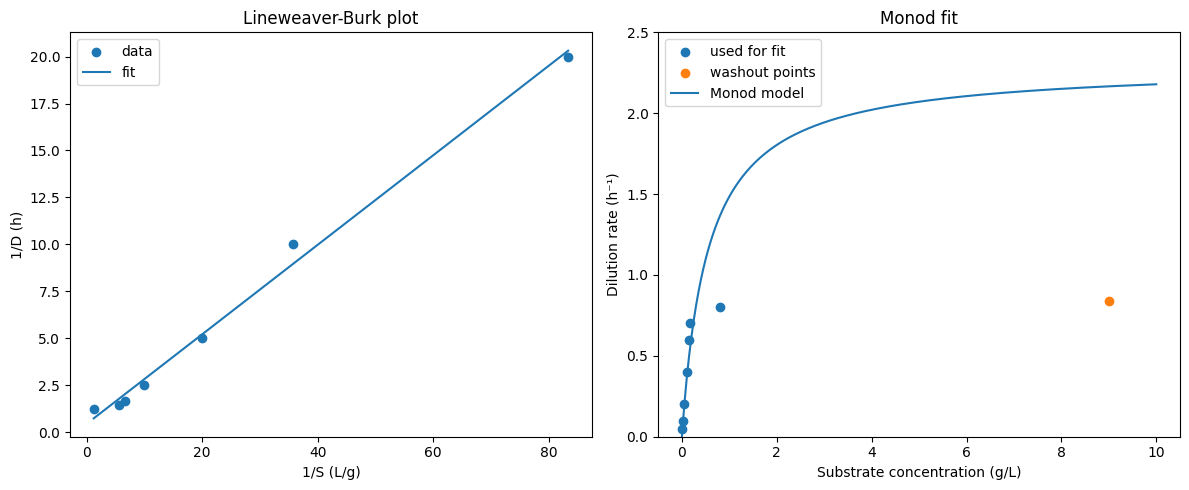

In [3]:
x = 1/S_fit
y = 1/D_fit

slope, intercept, _, _, _ = linregress(x, y)

mu_max = 1/intercept
Ks = slope * mu_max

print("mu_max =", mu_max)
print("Ks =", Ks)

def monod(S):
    return mu_max * S / (Ks + S)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Lineweaver-Burk plot ---
ax1.scatter(x, y, label="data")
x_fit = np.linspace(min(x), max(x), 200)
ax1.plot(x_fit, slope * x_fit + intercept, label="fit")
ax1.set_xlabel("1/S (L/g)")
ax1.set_ylabel("1/D (h)")
ax1.set_title("Lineweaver-Burk plot")
ax1.legend()

# --- Monod plot ---
ax2.scatter(S_fit, D_fit, label="used for fit")
ax2.scatter(S[7:], D[7:], label="washout points")
S_range = np.linspace(0, 10, 200)
ax2.plot(S_range, monod(S_range), label="Monod model")
ax2.set_xlabel("Substrate concentration (g/L)")
ax2.set_ylabel("Dilution rate (h⁻¹)")
ax2.set_ylim(0, 2.5)
ax2.set_title("Monod fit")
ax2.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_A_combined.png")
plt.show()

### Part (b): Estimate $Y_{X/S}$ and maintenance coefficient $m$

From the substrate balance at steady state:
$$D(S_0 - S) = \frac{D \cdot X}{Y_{X/S}} + m \cdot X$$

Rearranging:
$$\frac{D(S_0 - S)}{X} = \frac{D}{Y_{X/S}} + m$$

This is linear in $D$: plot $\frac{D(S_0-S)}{X}$ vs $D$, slope $= 1/Y_{X/S}$, intercept $= m$.

Yxs = 0.5185485105794473
m = 0.0871657143562179


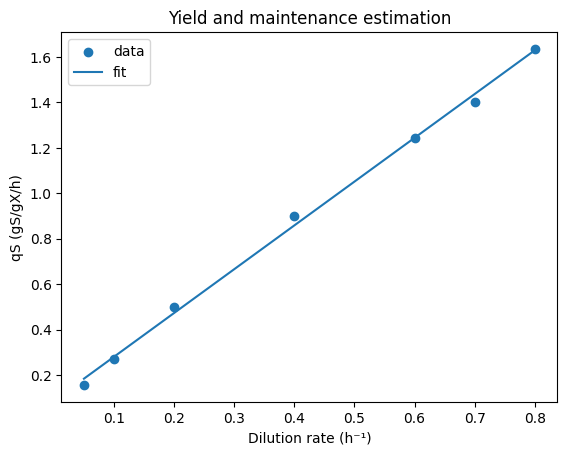

In [23]:
qS = D_fit*(S0-S_fit)/X_fit

slope_b, intercept_b, _, _, _ = linregress(D_fit,qS)

Yxs = 1/slope_b
m = intercept_b

print("Yxs =",Yxs)
print("m =",m)

plt.figure()

plt.scatter(D_fit,qS,label="data")

D_line = np.linspace(min(D_fit),max(D_fit),200)

plt.plot(D_line,slope_b*D_line + intercept_b,label="fit")

plt.xlabel("Dilution rate (h⁻¹)")
plt.ylabel("qS (gS/gX/h)")

plt.legend()
plt.title("Yield and maintenance estimation")
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_B.png")
plt.show()

### Part (c): $D_{max}$ and $D_{opt}$ (ignoring maintenance)

##### Derivation of $D_{max}$

At steady state the Monod equation equals the dilution rate:
$$\mu = D = \frac{\mu_{max} S}{K_s + S}$$

Solving for the steady-state substrate concentration $S$:
$$D(K_s + S) = \mu_{max} S$$
$$D K_s = (\mu_{max} - D)\, S$$
$$\boxed{S(D) = \frac{D\, K_s}{\mu_{max} - D}}$$

As $D$ increases, $S$ increases. Washout occurs when the reactor substrate concentration reaches the feed concentration, i.e. $S \to S_0$ (no substrate is consumed because there is no biomass left). Setting $S = S_0$:
$$S_0 = \frac{D_{max}\, K_s}{\mu_{max} - D_{max}}$$
$$S_0(\mu_{max} - D_{max}) = D_{max}\, K_s$$
$$S_0\,\mu_{max} = D_{max}(K_s + S_0)$$
$$\boxed{D_{max} = \frac{\mu_{max}\, S_0}{K_s + S_0}}$$

##### Derivation of $D_{opt}$ (maximum biomass productivity)

**Step 1: Write $X$ as a function of $D$ (no maintenance, $m=0$).**

The steady-state substrate balance simplifies to:
$$D(S_0 - S) = \frac{D\,X}{Y_{X/S}} \implies X = Y_{X/S}(S_0 - S)$$

Substituting $S(D)$ from above:
$$X(D) = Y_{X/S}\left(S_0 - \frac{D\,K_s}{\mu_{max}-D}\right) = Y_{X/S}\cdot\frac{S_0(\mu_{max}-D) - D\,K_s}{\mu_{max}-D}$$
$$\boxed{X(D) = Y_{X/S}\cdot\frac{\mu_{max}S_0 - D(K_s+S_0)}{\mu_{max}-D}}$$

**Step 2: Form the productivity $P = D \cdot X$.**

Let $A = \mu_{max}S_0$ and $B = K_s + S_0$ for brevity:
$$P(D) = D \cdot X(D) = Y_{X/S}\cdot\frac{D(A - B\,D)}{\mu_{max}-D}$$

**Step 3: Differentiate $P$ with respect to $D$ and set to zero.**

Using the quotient rule on $f(D) = \dfrac{D(A-BD)}{\mu_{max}-D}$:

Numerator of $f$: $u = D(A-BD) = AD - BD^2$, so $u' = A - 2BD$  
Denominator: $v = \mu_{max}-D$, so $v' = -1$

$$f'(D) = \frac{u'v - uv'}{v^2} = \frac{(A-2BD)(\mu_{max}-D) + D(A-BD)}{(\mu_{max}-D)^2}$$

Setting $f'(D)=0$ means the numerator must vanish:
$$(A-2BD)(\mu_{max}-D) + D(A-BD) = 0$$

Expanding:
$$A\mu_{max} - AD - 2BD\mu_{max} + 2BD^2 + AD - BD^2 = 0$$
$$A\mu_{max} - 2BD\mu_{max} + BD^2 = 0$$

Dividing by $B$:
$$D^2 - 2\mu_{max}D + \frac{A}{B}\mu_{max} = 0$$

Recall $A/B = \mu_{max}S_0/(K_s+S_0)$, so:
$$D^2 - 2\mu_{max}D + \frac{\mu_{max}^2 S_0}{K_s+S_0} = 0$$

**Step 4: Solve the quadratic.**

$$D = \frac{2\mu_{max} \pm \sqrt{4\mu_{max}^2 - 4\,\dfrac{\mu_{max}^2 S_0}{K_s+S_0}}}{2} = \mu_{max}\left(1 \pm \sqrt{1 - \frac{S_0}{K_s+S_0}}\right)$$

$$= \mu_{max}\left(1 \pm \sqrt{\frac{K_s}{K_s+S_0}}\right)$$

The ($+$) root exceeds $D_{max}$ (non-physical), so we take the ($-$) root:

$$\boxed{D_{opt} = \mu_{max}\left(1 - \sqrt{\frac{K_s}{K_s+S_0}}\right)}$$

In [24]:
D_max = mu_max*S0/(Ks+S0)

print("D_max =",D_max)

def S_nom(D):
    return Ks*D/(mu_max-D)

def X_nom(D):
    return Yxs*(S0-S_nom(D))

def productivity_nom(D):
    return D*X_nom(D)

D_range = np.linspace(0.001,0.99*D_max,500)

prod_nom = productivity_nom(D_range)

D_opt_nom = D_range[np.argmax(prod_nom)]

print("Optimal D (no maintenance) =",D_opt_nom)

D_max = 2.17874525028203
Optimal D (no maintenance) = 1.7724282506803124


### Part (d): X and S as functions of D (with maintenance)

At steady state, combining the Monod equation with the substrate balance:

$$S(D) = \frac{D \cdot K_s}{\mu_{max} - D}$$

$$X(D) = \frac{Y_{X/S}(S_0 - S)}{1 + m \cdot Y_{X/S}/D}$$

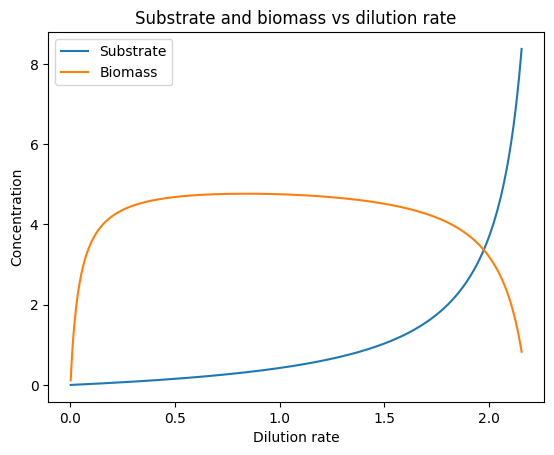

In [25]:
def solve_system(D_val):

    def equations(vars):

        S_var, X_var = vars

        mu = mu_max*S_var/(Ks+S_var)

        eq1 = mu - D_val

        eq2 = D_val*(S0-S_var) - (D_val*X_var/Yxs + m*X_var)

        return [eq1,eq2]

    sol = fsolve(equations,[0.1,2])

    return sol


S_vals = []
X_vals = []

for d in D_range:

    s,x = solve_system(d)

    S_vals.append(s)
    X_vals.append(x)

S_vals = np.array(S_vals)
X_vals = np.array(X_vals)

plt.figure()
plt.plot(D_range,S_vals,label="Substrate")
plt.plot(D_range,X_vals,label="Biomass")
plt.xlabel("Dilution rate")
plt.ylabel("Concentration")
plt.legend()
plt.title("Substrate and biomass vs dilution rate")
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_D.png")
plt.show()

### Part (e): Productivity $D \cdot X$ vs D; effect of $K_s$

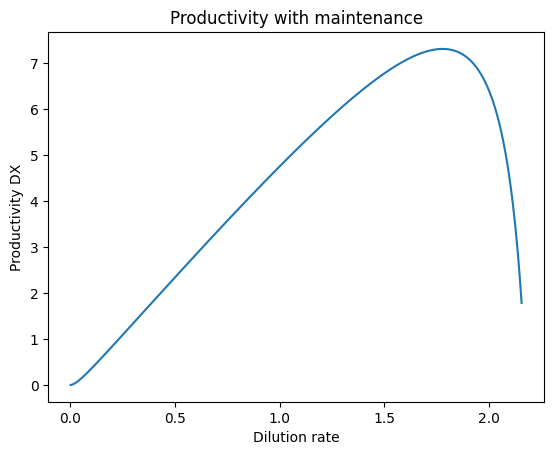

In [26]:
productivity = D_range*X_vals

plt.figure()
plt.plot(D_range,productivity)
plt.xlabel("Dilution rate")
plt.ylabel("Productivity DX")
plt.title("Productivity with maintenance")
plt.show()

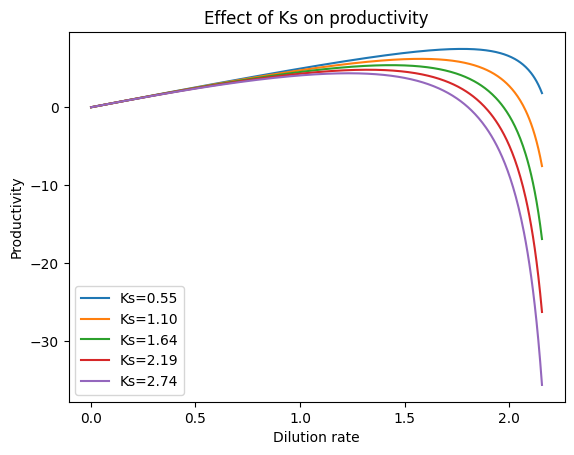

In [27]:
Ks_values = [Ks, Ks*2, Ks*3, Ks*4, Ks*5]

plt.figure()

for Ks_test in Ks_values:

    def S_test(D):
        return Ks_test*D/(mu_max-D)

    X_test = Yxs*(S0-S_test(D_range))

    P_test = D_range*X_test

    plt.plot(D_range,P_test,label=f"Ks={Ks_test:.2f}")

plt.xlabel("Dilution rate")
plt.ylabel("Productivity")
plt.legend()
plt.title("Effect of Ks on productivity")
plt.savefig(r"C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_E_2.png")
plt.show()

### Part (f): Maximum productivity and corresponding $D$ (with the $K_s$ from part a)

In [28]:
P_max = np.max(productivity)

D_best = D_range[np.argmax(productivity)]

print("Maximum productivity =",P_max)

print("Dilution rate for maximum productivity =",D_best)

Maximum productivity = 7.306375497376747
Dilution rate for maximum productivity = 1.781069364098265


## Part (g): Compare $D_{opt}$ from (c) and (f)

In [29]:
print("Optimal D ignoring maintenance =",D_opt_nom)

print("Optimal D including maintenance =",D_best)

Optimal D ignoring maintenance = 1.7724282506803124
Optimal D including maintenance = 1.781069364098265
